La **fórmula de Widmark** proporciona una estimació del tant per cent d'alcohol en sang (BAC, per les seves sigles en anglès). La seva expressió és la següent:

$$BAC = k \frac{n V \frac{\%}{100} }{mr}-\lambda t.$$

On $k$ és una constant per redimensionalitzar amb valor aproximat $k=0.079 \ kg/mL$,

 $n$ és la quantitat de copes/llaunes/botelles d'alcohol de volum $V$ en mL i tant per cent $\%$ en alcohol,

 $m$ és la massa de la persona en quilograms,

 $r$ és una constant que depèn del sexe de la persona, si és home $r=0.68$ i si és dona $r=0.55$,

 $\lambda$ és la taxa d'eliminació d'alcohol i pren un valor aproximat de $\lambda=0.015$ % d'alcohol en sang per hora,

 i $t$ és el temps en hores des de la darrera consumició.


A major percentatge d'alcohol en sang (BAC), major nivell d'intoxicació. Per exemple, un BAC de 0,04 % provoca una eufòria lleu, major inhibició, temps de reacció més lent; un BAC de 0,08 % és el límit legal per conduir i es comença a tenir problemes per parlar i per moure-se; un BAC de 0,20% indica una intoxicació greu, de fet, hi ha una alta probabilitat de vòmits, desequilibris i confusions extremes; per acabar, un BAC de 0,40% implica un risc mortal alt per depressió respiratòria o aturada cardíaca.

Com es veu, el BAC té una dependència lineal creixent amb la quantitat de llaunes/botelles d'alcohol i decreixent amb el temps. Es pot observar aquest darrer fet en el següent gràfic, en el qual s'ha emprat uns valors comuns com: $m=70$ kg, $V=330$ mL i $4.8$ % d'alcohol (que podria ser una cervesa):

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
def BAC(n, V, p, m, r, t):
  BAC = 0.07876529054 * n * V * p / (100 * m * r) - 0.015 * t
  return np.maximum(BAC, -0.1)

In [ ]:
# Paràmetres de prova:
m = 70
V = 330
p = 4.8

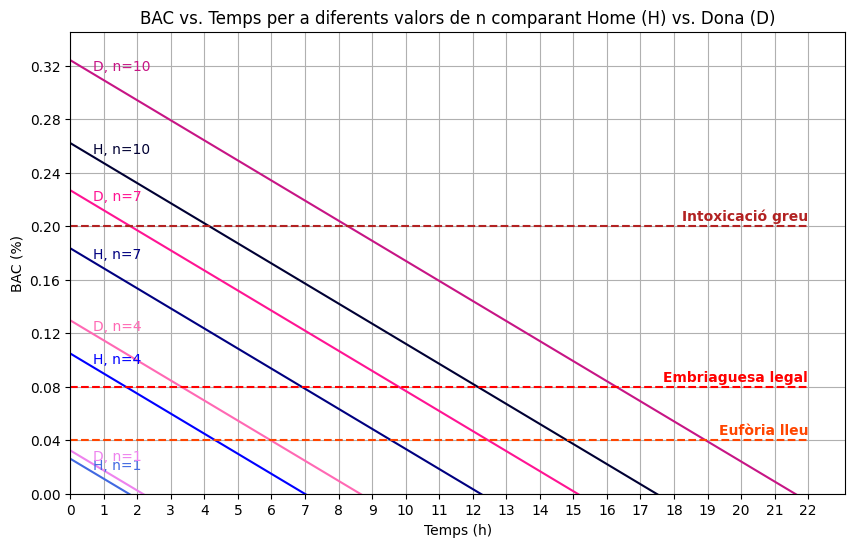

In [ ]:
# Graficar BAC en funció del temps t en hores passat per diferents valors de n:
t_values = np.linspace(0, 22, 100)  # Variar el temps de 0 a 18 hores
fig, ax = plt.subplots(figsize=(10, 6))

# Llista de colors per homes (blau) i dones (rosa)
colors_men = ['#4169E1', '#0000FF', '#000080', '#000033']
colors_women = ['#EE82EE', '#FF69B4', '#FF1493', '#C71585']

# Graficar homes r=0.68
for i, n in enumerate(range(1, 11 + 1, 3)):
    bac_vs_t_men = BAC(n=n, V=V, p=p, m=m, r=0.68, t=t_values)
    ax.plot(t_values, bac_vs_t_men, color=colors_men[i % len(colors_men)])
    ax.text(t_values[3], bac_vs_t_men[3], f'H, n={n}', color=colors_men[i % len(colors_men)], ha='left', va='bottom')



# Graficar dones r=0.55
for i, n in enumerate(range(1, 11 + 1, 3)):
    bac_vs_t_women = BAC(n=n, V=V, p=p, m=m, r=0.55, t=t_values)
    ax.plot(t_values, bac_vs_t_women, color=colors_women[i % len(colors_women)])
    ax.text(t_values[3], bac_vs_t_women[3], f'D, n={n}', color=colors_women[i % len(colors_women)], ha='left', va='bottom')




# Graficar diferents nivells d'intoxicació
ax.plot(t_values, np.full_like(t_values, 0.04), color='#FF4500', linestyle='--')
ax.text(22, 0.042, 'Eufòria lleu', color='#FF4500', ha='right', va='bottom', fontweight='bold')
ax.plot(t_values, np.full_like(t_values, 0.08), color='#FF0000', linestyle='--')
ax.text(22, 0.082, 'Embriaguesa legal', color='#FF0000', ha='right', va='bottom', fontweight='bold')
ax.plot(t_values, np.full_like(t_values, 0.20), color='#B22222', linestyle='--')
ax.text(22, 0.202, 'Intoxicació greu', color='#B22222', ha='right', va='bottom', fontweight='bold')

# Configuració del gràfic
ax.set_xlabel('Temps (h)')
ax.set_ylabel('BAC (%)')
ax.set_title('BAC vs. Temps per a diferents valors de n comparant Home (H) vs. Dona (D)')
ax.set_ylim(0)
ax.set_xlim(0)
ax.set_xticks(np.arange(0,23,1))
ax.set_yticks(np.arange(0, 0.34, 0.04))
ax.grid()
plt.show()

Aquest gràfic és útil per saber quantes hores han de passar perquè es redueixi a zero la quantitat d'alcohol en sang, sabent quantes copes has près. Per exemple, si un home pren 4 copes, ha d'esperar fins a 7 hores per conduir amb completa seguretat. Ara bé, com es veu a la gràfica, per la mateixa quantitat de copes ingerides, les dones tarden més (a l'exemple anterior, tardaria fins a, quasi, 9 hores). Això és deu al fet que les dones tenen un percentatge de grassa corporal més alt i menys aigua corporal, d'aquesta forma, l'alcohol es dilueix menys. Aquest és el motiu pel qual les dones tenen un BAC major i, per tant, un temps fins a l'eliminació total d'alcohol major.

Aquest temps, pel qual l'alcohol es redueix fins a zero, es pot calcular a partir de l'equació del BAC, imposant BAC = 0. D'aquesta forma s'obté:

$$ t_{0\%}= \frac{k}{\lambda} \frac{nV\frac{\%}{100}}{mr}. $$

Cal remarcar com, per exemple, no és després de 8 hores, que les dones que hagin pres 10 copes deixin d'estar en un nivell d'intoxicació greu. És curiós observar la quantitat de temps que ha de passar fins que l'alcohol es redueixi fins a un cert nivell en funció de les copes begudes. Ha de passar molt de temps des de la darrera ingestió perquè es redueixi a nivells baixos de BAC.

Per poder observar la quantitat de copes que s'han de beure per tenir un cert BAC després d'un temps determinat s'aillarà $n$ de l'equació i es representarà per diferents temps:

$$n = \frac{mr(BAC+\lambda t)}{kV\frac{\%}{100}} .$$

In [ ]:
def nombre_llaunes(m, r, BAC, t, V, p):
  return 100*m*r*(BAC+0.015*t)/(0.07876529054*V*p)

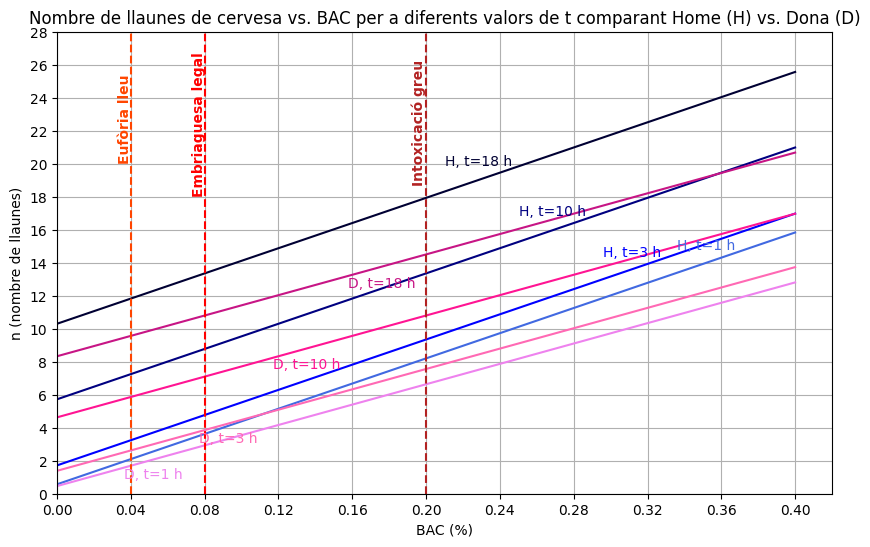

In [ ]:
# Graficar BAC en funció del temps t en hores passat per diferents valors de n:
BAC_values = np.linspace(0, 0.40, 100)  # Variar el BAC
t_i_values = [1, 3, 10, 18]
fig, ax = plt.subplots(figsize=(10, 6))

# Llista de colors per homes (blau) i dones (rosa)
colors_men = ['#4169E1', '#0000FF', '#000080', '#000033']
colors_women = ['#EE82EE', '#FF69B4', '#FF1493', '#C71585']


# Graficar homes r=0.68
k = 9
for i, t in enumerate(t_i_values):
    n_vs_BAC_men = nombre_llaunes(m=m, r=0.68, BAC=BAC_values, t=t, V=V, p=p)
    ax.plot(BAC_values, n_vs_BAC_men, color=colors_men[i % len(colors_men)])
    ax.text(BAC_values[-k], n_vs_BAC_men[-k], f'H, t={t} h', color=colors_men[i % len(colors_men)], ha='right', va='bottom')
    k += 10

# Graficar dones r=0.55
k = 9
for i, t in enumerate(t_i_values):
    n_vs_BAC_women = nombre_llaunes(m=m, r=0.55, BAC=BAC_values, t=t, V=V, p=p)
    ax.plot(BAC_values, n_vs_BAC_women, color=colors_women[i % len(colors_women)])
    ax.text(BAC_values[k], n_vs_BAC_women[k], f'D, t={t} h', color=colors_women[i % len(colors_women)], ha='left', va='top')
    k += 10

# Graficar diferents nivells d'intoxicació
ax.axvline(x=0.04, color='#FF4500', linestyle='--')
ax.text(0.033, 20, 'Eufòria lleu', color='#FF4500', ha='left', va='bottom', fontweight='bold', rotation=90)
ax.axvline(x=0.08, color='#FF0000', linestyle='--')
ax.text(0.073, 18, 'Embriaguesa legal', color='#FF0000', ha='left', va='bottom', fontweight='bold', rotation=90)
ax.axvline(x=0.2, color='#B22222', linestyle='--')
ax.text(0.192, 18.7, 'Intoxicació greu', color='#B22222', ha='left', va='bottom', fontweight='bold', rotation=90)

# Configuració del gràfic
ax.set_ylabel('n (nombre de llaunes)')
ax.set_xlabel('BAC (%)')
ax.set_title('Nombre de llaunes de cervesa vs. BAC per a diferents valors de t comparant Home (H) vs. Dona (D)')
ax.set_ylim(0)
ax.set_xlim(0)
ax.set_xticks(np.arange(0,0.41,0.04))
ax.set_yticks(np.arange(0,30,2))
ax.grid()
plt.show()

Aquest gràfic és pot interpretar com l'estat en el qual pot estar una persona després de tantes hores d'haver begut alcohol, segons quantes copes has begut. Per exemple, si al dia següent la persona té un examen, pot saber quin nivell d'intoxicació tendrà si s'enrecorda de quantes copes vas beure. Una dona que tengui un examen al matí següent d'haver sortit de festa i haver begut 6 copes, més o menys, assumint unes 10 hores des de la darrera ingestió, encar així, tendria un BAC=0,04 %, la qual cosa implicaria un mal desenvolupament a l'hora de fer l'examen. Un home en la mateixa situació, podria haver arribat a beure quasi 8 copes.
En aquest gràfic també es pot observar un fer que ja s'ha comentat a l'anterior i és que pel mateix temps, les dones necessiten una quantitat menor de copes begudes per tenir el mateix BAC que els homes.

Ara bé, com s'ha dit, és una estimació, ja que no té tot en compte. De fet, només té en compte el temps després de la darrera consumició, sense tenir en compte com canvia el BAC entre copa i copa i en quin nivell s'estava abans de la darrera consumició. Una millora podria ser graficar com evoluciona BAc consumició darrera consumició, tenint en compte el temps entre mitges.